In [1]:
import pandas as pd 

In [2]:
df=pd.read_csv('population_total.csv')

In [3]:
df

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09
...,...,...,...
4180,United States,1965.0,1.997337e+08
4181,United States,1960.0,1.867206e+08
4182,United States,1955.0,1.716853e+08
4183,India,1960.0,4.505477e+08


1 Making a pivot table 

.pivot(): Returns reshaped dataframe organized by given index / column values (pivot without aggregation)

In [4]:
# dropping null values 
df=df.dropna()

In [5]:
# making a pivot table 
pivot_df=df.pivot(index='year',columns='country',values='population')

In [6]:
pivot_df.columns

Index(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       ...
       'Uruguay', 'Uzbekistan', 'Vanuatu', 'Venezuela', 'Vietnam',
       'Wallis & Futuna', 'Western Sahara', 'Yemen', 'Zambia', 'Zimbabwe'],
      dtype='object', name='country', length=234)

In [56]:
pivot_df

country,India,United States,Brazil,China
year,,,,
1955.0,4.098806e+08,171685336.0,62533919.0,6.122416e+08
1960.0,4.505477e+08,186720571.0,72179226.0,6.604081e+08
1965.0,4.991233e+08,199733676.0,83373530.0,7.242190e+08
1970.0,5.551898e+08,209513341.0,95113265.0,8.276014e+08
1975.0,6.231029e+08,219081251.0,107216205.0,9.262409e+08
1980.0,6.989528e+08,229476354.0,120694009.0,1.000089e+09
1985.0,7.843600e+08,240499825.0,135274080.0,1.075589e+09
1990.0,8.732778e+08,252120309.0,149003223.0,1.176884e+09
1995.0,9.639226e+08,265163745.0,162019896.0,1.240921e+09


In [7]:
# selecting some contries
pivot_df=pivot_df[['India','United States','Brazil','China']]

2 Data visualization

1 Lineplot

<Axes: title={'center': 'Population graph'}, xlabel='Year', ylabel='population'>

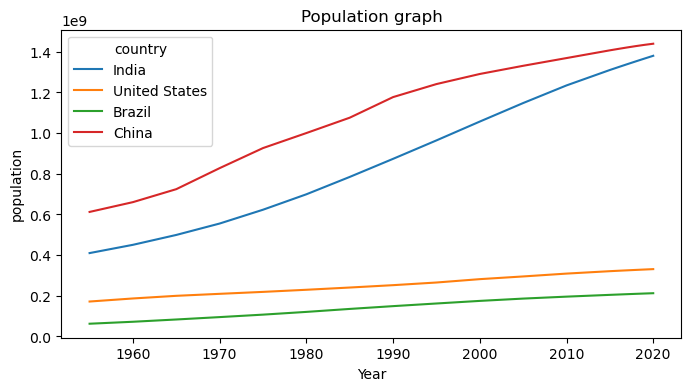

In [8]:
pivot_df.plot(kind='line',xlabel='Year',ylabel='population',title='Population graph',
             figsize=(8,4))

2 Barplot

2.1 Single Barplot

In [9]:
# Selecting only one year (2020)
df20=pivot_df[pivot_df.index.isin([2020])]

In [10]:
df20

country,India,United States,Brazil,China
year,,,,
2020.0,1.380004e+09,331002651.0,212559417.0,1.439324e+09


In [11]:
# transpose dataframe from rows to columns or viceversa 
df20=df20.T

<Axes: title={'center': '2020 Population'}, xlabel='year', ylabel='population'>

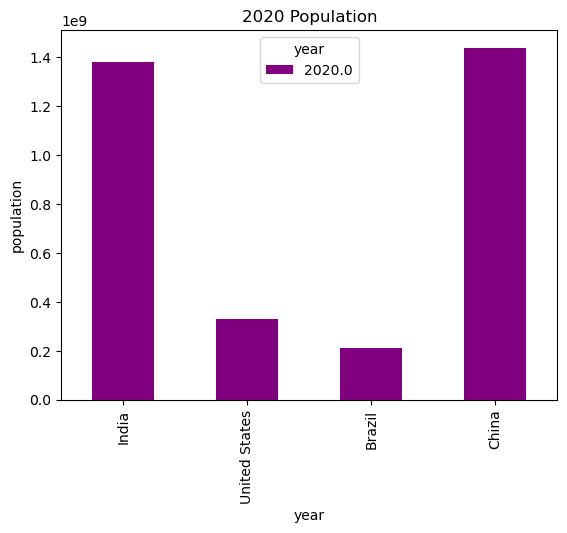

In [12]:
# making barplot
df20.plot(kind='bar',color='purple',xlabel='year',ylabel='population',title ="2020 Population")

2.2 Barplot grouped by "n " variables

In [13]:
pivot_df

country,India,United States,Brazil,China
year,,,,
1955.0,4.098806e+08,171685336.0,62533919.0,6.122416e+08
1960.0,4.505477e+08,186720571.0,72179226.0,6.604081e+08
1965.0,4.991233e+08,199733676.0,83373530.0,7.242190e+08
1970.0,5.551898e+08,209513341.0,95113265.0,8.276014e+08
1975.0,6.231029e+08,219081251.0,107216205.0,9.262409e+08
1980.0,6.989528e+08,229476354.0,120694009.0,1.000089e+09
1985.0,7.843600e+08,240499825.0,135274080.0,1.075589e+09
1990.0,8.732778e+08,252120309.0,149003223.0,1.176884e+09
1995.0,9.639226e+08,265163745.0,162019896.0,1.240921e+09


In [14]:
# selecting a few years 
df_sample=pivot_df[pivot_df.index.isin([1980,1990,2000,2010,2020])]

<Axes: xlabel='Year', ylabel='Population'>

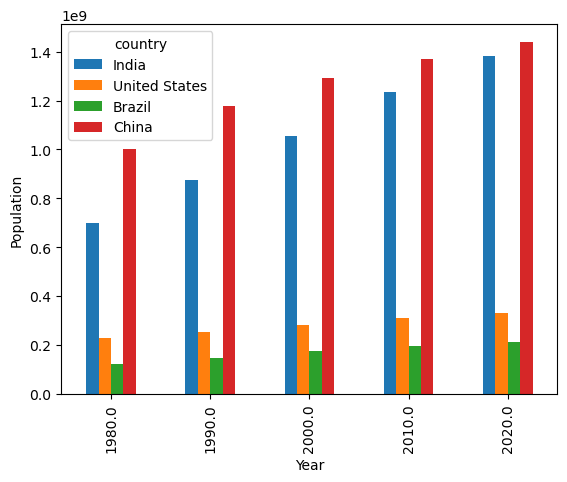

In [15]:
# making grouped barplot
df_sample.plot(kind='bar',xlabel='Year',ylabel='Population')

3 piechart

In [18]:
# changing column name 
df20

year,2020.0
country,
India,1.380004e+09
United States,3.310027e+08
Brazil,2.125594e+08
China,1.439324e+09


In [22]:
df20.rename(columns={2020:'2020'},inplace=True)

<Axes: title={'center': 'Piechart of population'}, ylabel='2020'>

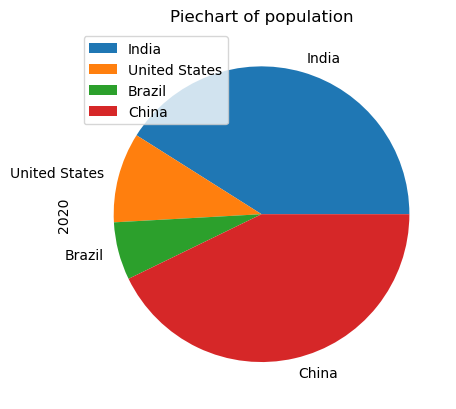

In [25]:
df20.plot(kind="pie",y='2020',title='Piechart of population')

4 BOXPLOT

5.1 Single Boxplot

In [27]:
df_sample

country,India,United States,Brazil,China
year,,,,
1980.0,6.989528e+08,229476354.0,120694009.0,1.000089e+09
1990.0,8.732778e+08,252120309.0,149003223.0,1.176884e+09
2000.0,1.056576e+09,281710909.0,174790340.0,1.290551e+09
2010.0,1.234281e+09,309011475.0,195713635.0,1.368811e+09
2020.0,1.380004e+09,331002651.0,212559417.0,1.439324e+09


<Axes: ylabel='Population'>

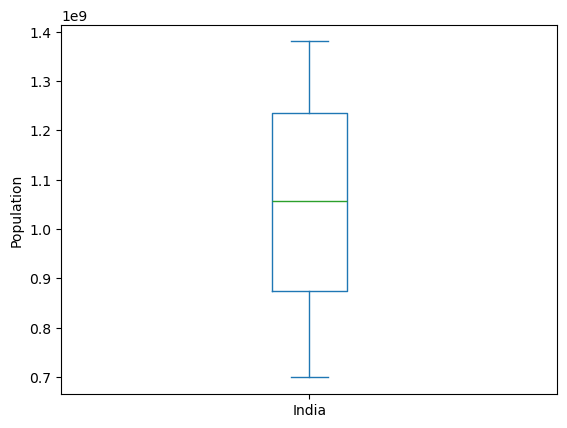

In [29]:
df_sample['India'].plot(kind='box' ,ylabel="Population")

4.2 Multiple boxplot

<Axes: ylabel='Population'>

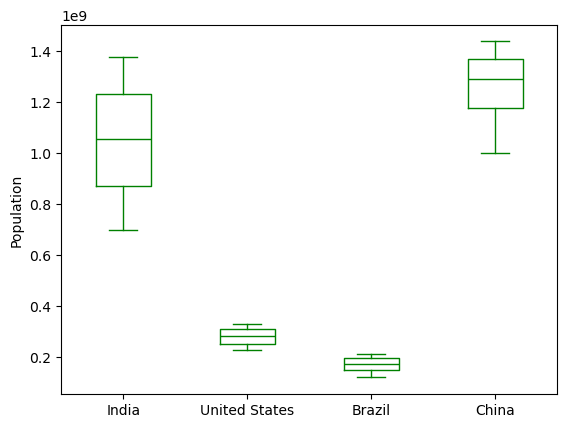

In [35]:
df_sample.plot(kind='box',color='green',ylabel='Population')

5 Histogram

<Axes: ylabel='Frequency'>

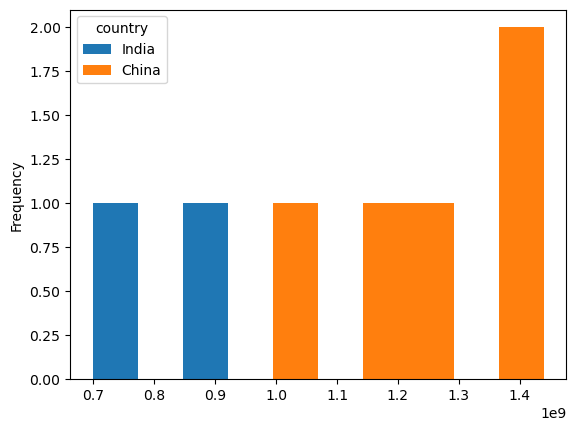

In [40]:
df_sample[['India','China']] .plot(kind='hist') 

6 ScatterPlot

In [41]:
# selecting a sample of the raw data 
df_sample

country,India,United States,Brazil,China
year,,,,
1980.0,6.989528e+08,229476354.0,120694009.0,1.000089e+09
1990.0,8.732778e+08,252120309.0,149003223.0,1.176884e+09
2000.0,1.056576e+09,281710909.0,174790340.0,1.290551e+09
2010.0,1.234281e+09,309011475.0,195713635.0,1.368811e+09
2020.0,1.380004e+09,331002651.0,212559417.0,1.439324e+09


In [50]:
df_sample2=df[df['country'].isin(['India','United States','China','Brazil'])]

<Axes: xlabel='year', ylabel='population'>

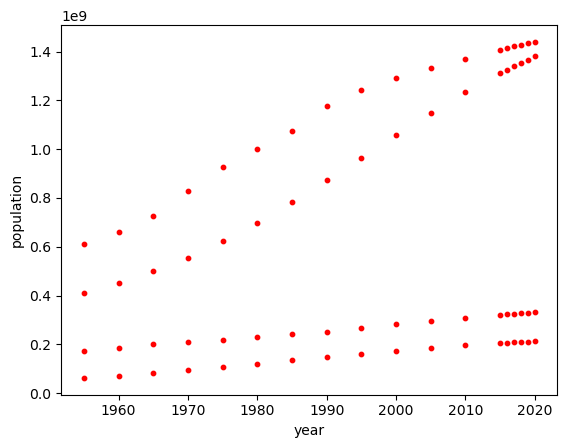

In [55]:
df_sample2.plot(kind='scatter',
               x='year',
               y='population',
               s=10,color='red')